In [1]:
# 1. Train a Traditional XGBoost Baseline (using TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import pandas as pd

from transformers import AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset, Dataset, DatasetDict
import torch

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [2]:
from pathlib import Path

# 1. Get the directory where THIS script is saved
# .resolve() ensures we have the full absolute path
base_dir = Path.cwd()

# 2. Define your file paths using the / operator
# Pathlib automatically handles Windows vs Mac/Linux slashes
df_path = base_dir / "data/processed_data/all_data.csv"


In [3]:
df = pd.read_csv(df_path, index_col=0)

In [4]:
df.head()

,Description,Source,Rent
0,WF Credit Card AUTO PAY 260102 OOOOO OOOOO,real,0
1,WF Credit Card AUTO PAY 260101 OOOOO OOOOO,real,0
2,ZELLE FROM OOOOO ON 12/26 REF # COF2H8DF53VH K...,real,0
3,FEDERAL NATIONAL PAYROLL 251226 939238644926DV...,real,0
4,BENEFIT PAYMENT EDI PYMNTS OOOOO OOOOO,real,0


In [5]:
df.duplicated().sum()

535

In [6]:
# Show all duplicate rows (include all occurrences)
duplicates = df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
duplicates

,Description,Source,Rent
508,AGRI TREAS 310 FED SAL,real,0
514,AGRI TREAS 310 FED SAL,real,0
523,AGRI TREAS 310 FED SAL,real,0
538,AGRI TREAS 310 FED SAL,real,0
544,AGRI TREAS 310 FED SAL,real,0
...,...,...,...
459,ZEL ZELLE TO LIU BAOZHU,real,1
465,ZEL ZELLE TO LIU BAOZHU,real,1
477,ZEL ZELLE TO LIU BAOZHU,real,1
489,ZEL ZELLE TO LIU BAOZHU,real,1


In [7]:
duplicates.Description.unique()

array(['AGRI TREAS 310   FED SAL ', 'BECU CK WEBXFR TRANSFER ',
       'BENEFIT PAYMENT EDI PYMNTS OOOOO OOOOO',
       'CHASE CREDIT CRD AUTOPAY ',
       'DDA WITHDRAW AP TW04C886   3028 WILSON BLVD            ARLINGTON     * VA',
       'DEP CITIZE SV WEBXFR 1770527921  BR P2P ZUOYANG LI',
       'DEP TD BANK NA 1770527921  BR ZELLE JOYCE WANG',
       'DEPT EDUCATION   STUDENT LN                 PPD ID: 9102001001',
       'DIR BENEFIT PAYMENT N943351864  BR EDI PYMNTS',
       'DIR FANNIE MAE 9111111101  BR DIRECT DEP',
       'DIR FEDERAL NATIONAL 9111111101  BR DIRECT DEP',
       'DIR FEDERAL NATIONAL 9111111101  BR PAYROLL',
       'DIR PAYPAL PAYPALSD11  BR TRANSFER',
       'DIR PTC EZ PASS AUTO 0383913206  BR PAYMENT',
       'DIR VENMO 5264681992  BR CASHOUT',
       'ECK AMEX EPAYMENT 0005000008  BR ACH PMT',
       'ECK AMEX EPAYMENT 0005000040  BR ACH PMT',
       'ECK CITI AUTOPAY CITICARDAP  BR PAYMENT',
       'ECK CITIZE CK WEBXFR 3770527921  BR ETRANSFER',
       '

In [8]:
len(duplicates.Description.unique())

59

In [9]:
df = df.drop_duplicates().reset_index(drop=True)

df

,Description,Source,Rent
0,WF Credit Card AUTO PAY 260102 OOOOO OOOOO,real,0
1,WF Credit Card AUTO PAY 260101 OOOOO OOOOO,real,0
2,ZELLE FROM OOOOO ON 12/26 REF # COF2H8DF53VH K...,real,0
3,FEDERAL NATIONAL PAYROLL 251226 939238644926DV...,real,0
4,BENEFIT PAYMENT EDI PYMNTS OOOOO OOOOO,real,0
...,...,...,...
1345,RENT PAYMENT (MONTHLY) [TXN:953771],synthetic,1
1346,Unit payment for residential unit [Invoice:139...,synthetic,1
1347,Check #1234 for monthly [ID:20240918-67] [14:34],synthetic,1
1348,Quarterly dwelling [Payment:8AO1],synthetic,0


In [10]:
df.head()

,Description,Source,Rent
0,WF Credit Card AUTO PAY 260102 OOOOO OOOOO,real,0
1,WF Credit Card AUTO PAY 260101 OOOOO OOOOO,real,0
2,ZELLE FROM OOOOO ON 12/26 REF # COF2H8DF53VH K...,real,0
3,FEDERAL NATIONAL PAYROLL 251226 939238644926DV...,real,0
4,BENEFIT PAYMENT EDI PYMNTS OOOOO OOOOO,real,0


In [11]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=34783, stratify=df[['Source', 'Rent']])

In [12]:
df_train.shape, df_test.shape

((1080, 3), (270, 3))

In [13]:
df_train.head()

,Description,Source,Rent
590,Rent payment (primary residence) [TXN:262020],synthetic,1
305,T-MOBILE PCS SVC 1538749 WE...,real,0
524,Rant fee [ID:20250504-697] [22:58],synthetic,1
982,Separate from rent - deposit [TXN:840758],synthetic,0
726,Building payment [Invoice:884813],synthetic,0


In [14]:
df_train['Rent'].value_counts(), df_test['Rent'].value_counts()

(Rent
 0    672
 1    408
 Name: count, dtype: int64,
 Rent
 0    168
 1    102
 Name: count, dtype: int64)

In [15]:

# Assume `df_train` and `df_test` are your DataFrames with 'Description' and 'rent'
vectorizer = TfidfVectorizer(max_features=1000) # Limit features for efficiency
X_train_tfidf = vectorizer.fit_transform(df_train['Description'])
X_test_tfidf = vectorizer.transform(df_test['Description'])

clf = RandomForestClassifier(n_estimators=100)
clf.fit(X_train_tfidf, df_train['Rent'])
y_pred_traditional = clf.predict(X_test_tfidf)


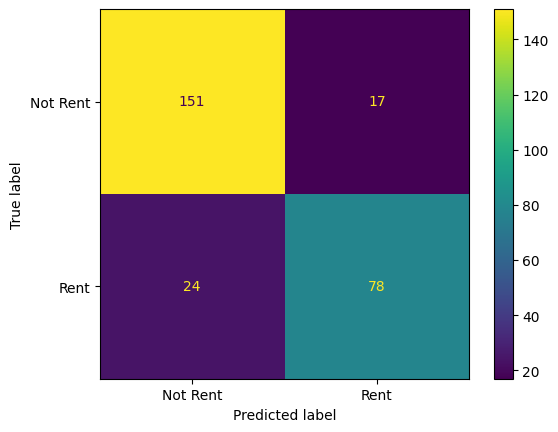

In [16]:


# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(df_test['Rent'], y_pred_traditional, display_labels=["Not Rent", "Rent"])
plt.show()


In [17]:
cm_traditional = confusion_matrix(df_test['Rent'], y_pred_traditional)

# 3. Extract the TP, TN, FP, FN values
# You can unpack the matrix or access elements by index
TN, FP, FN, TP = cm_traditional.ravel()

print(f"\nTN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# 4. Calculate the rates using the formulas
# False Positive Rate (FPR) = FP / (FP + TN)
# False Negative Rate (FNR) = FN / (FN + TP)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")


TN: 151, FP: 17, FN: 24, TP: 78
False Positive Rate (FPR): 0.1012
False Negative Rate (FNR): 0.2353


In [18]:

print("Traditional Model (TF-IDF + RandomForest) Performance:")
print(classification_report(df_test['Rent'], y_pred_traditional))


Traditional Model (TF-IDF + RandomForest) Performance:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       168
           1       0.82      0.76      0.79       102

    accuracy                           0.85       270
   macro avg       0.84      0.83      0.84       270
weighted avg       0.85      0.85      0.85       270



# 2. Train a Transformer-Based Model (using Hugging Face Transformers)

In [19]:

model_name = "distilbert-base-uncased"  # Good starting point for text classification
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)  # Binary classification
tokenizer = AutoTokenizer.from_pretrained(model_name)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
# Convert pandas DataFrames to Hugging Face Dataset objects
train_dataset = Dataset.from_pandas(df_train)
validation_dataset = Dataset.from_pandas(df_test)

# Combine into a DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset
})

In [21]:
def preprocess_function(examples):
    # Tokenize the transaction descriptions. Use truncation and padding for uniform length.
    return tokenizer(examples['Description'], truncation=True, padding='max_length', max_length=128)

# Apply the tokenization to the entire dataset
tokenized_dataset = dataset.map(preprocess_function, batched=True)

# Step 4: Format for PyTorch
# Rename the 'label' column to 'labels' (expected by the Trainer)
tokenized_dataset = tokenized_dataset.rename_column('Rent', 'labels')
# Set the format to return PyTorch tensors
tokenized_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

Map:   0%|          | 0/1080 [00:00<?, ? examples/s]

Map:   0%|          | 0/270 [00:00<?, ? examples/s]

In [22]:
from transformers import Trainer, TrainingArguments
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    """Function to compute accuracy and F1 score during evaluation."""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')  # Use 'macro' for multi-class
    return {'accuracy': acc, 'f1': f1}

# Step 5: Define Training Arguments
training_args = TrainingArguments(
    output_dir='./rent_classifier_results',  # Where to save the model
    eval_strategy='epoch',             # Evaluate at the end of each epoch
    save_strategy='epoch',                   # Save a checkpoint each epoch
    learning_rate=2e-5,                      # Standard learning rate for fine-tuning
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,                      # Number of training epochs
    weight_decay=0.01,
    load_best_model_at_end=True,             # Load the best model at the end
    metric_for_best_model='f1',              # Use F1 score to choose the best model
    push_to_hub=False,                       # Set to True if you want to upload to Hugging Face Hub
)

# Step 6: Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['validation'],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Step 7: Train the Model
trainer.train()

/var/folders/8x/6jjxqd7n5gj_5yxg2wdp9gkw0000gn/T/ipykernel_24470/226895045.py:29: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.363960,0.855556,0.802030
2,No log,0.323033,0.859259,0.822430
3,No log,0.326189,0.848148,0.787565


TrainOutput(global_step=204, training_loss=0.3862301695580576, metrics={'train_runtime': 143.2573, 'train_samples_per_second': 22.617, 'train_steps_per_second': 1.424, 'total_flos': 107298592911360.0, 'train_loss': 0.3862301695580576, 'epoch': 3.0})

In [23]:
# Get predictions on the validation set
y_pred_transformer = trainer.predict(tokenized_dataset['validation'])

# 'output' contains predictions (logits), label_ids, and metrics
logits_transformer = y_pred_transformer.predictions
true_labels_transformer = y_pred_transformer.label_ids

# Convert logits to class predictions (0 or 1)
pred_labels_transformer = np.argmax(logits_transformer, axis=1)


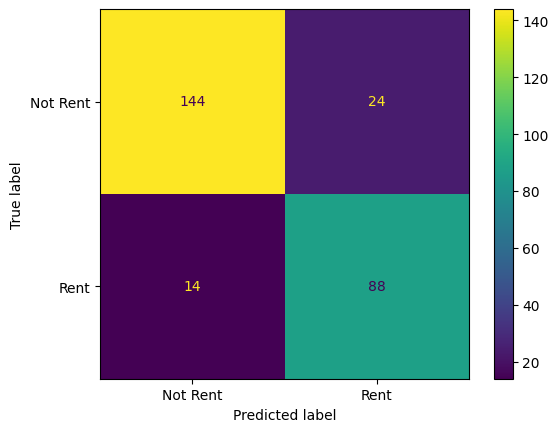

In [24]:


# Plot the confusion matrix
ConfusionMatrixDisplay.from_predictions(true_labels_transformer, pred_labels_transformer, display_labels=["Not Rent", "Rent"])
plt.show()


In [25]:
cm_transformer = confusion_matrix(true_labels_transformer, pred_labels_transformer)

# 3. Extract the TP, TN, FP, FN values
# You can unpack the matrix or access elements by index
TN, FP, FN, TP = cm_transformer.ravel()

print(f"\nTN: {TN}, FP: {FP}, FN: {FN}, TP: {TP}")

# 4. Calculate the rates using the formulas
# False Positive Rate (FPR) = FP / (FP + TN)
# False Negative Rate (FNR) = FN / (FN + TP)
false_positive_rate = FP / (FP + TN)
false_negative_rate = FN / (FN + TP)

print(f"False Positive Rate (FPR): {false_positive_rate:.4f}")
print(f"False Negative Rate (FNR): {false_negative_rate:.4f}")


TN: 144, FP: 24, FN: 14, TP: 88
False Positive Rate (FPR): 0.1429
False Negative Rate (FNR): 0.1373


In [26]:

print("Transformer Model Performance:")
print(classification_report(true_labels_transformer, pred_labels_transformer))


Transformer Model Performance:
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       168
           1       0.79      0.86      0.82       102

    accuracy                           0.86       270
   macro avg       0.85      0.86      0.85       270
weighted avg       0.86      0.86      0.86       270



In [27]:

print("Traditional Model (TF-IDF + RandomForest) Performance:")
print(classification_report(df_test['Rent'], y_pred_traditional))


Traditional Model (TF-IDF + RandomForest) Performance:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       168
           1       0.82      0.76      0.79       102

    accuracy                           0.85       270
   macro avg       0.84      0.83      0.84       270
weighted avg       0.85      0.85      0.85       270



In [29]:
scoreout_df = df_test.reset_index(drop=True)
scoreout_df['Traditional_Pred'] = pred_labels_transformer
scoreout_df['Transformer_Pred'] = y_pred_traditional

In [30]:
scoreout_df

,Description,Source,Rent,Traditional_Pred,Transformer_Pred
0,Subscription 10th recurring [Trans:226791],synthetic,0,0,0
1,Building disbursement for residential unit [Pa...,synthetic,1,1,1
2,NOT rent - utilities [Ref:209103],synthetic,0,0,0
3,Complex fee [TXN:970775] [03:26],synthetic,0,0,0
4,Rent payment (apartment) #235159,synthetic,1,1,1
...,...,...,...,...,...
265,UTILITY - MONTHLY [Payment:BFW0],synthetic,0,0,0
266,Check #1234 for monthly #204655,synthetic,0,1,0
267,Monthly housing and utilities bundle [TXN:895871],synthetic,1,1,1
268,Property remittance [ID:20240330-497],synthetic,0,1,1


In [31]:
scoreout_df.to_csv(base_dir / "data/processed_data/prediction_comparison.csv")

In [33]:
scoreout_real_df = scoreout_df[scoreout_df['Source']!= 'synthetic']

scoreout_real_df

,Description,Source,Rent,Traditional_Pred,Transformer_Pred
11,FANNIE MAE DIRECT DEP 250221 555093800464P22 O...,real,0,0,0
12,ZEL ZELLE FROM MARTINEZ JARON,real,0,0,0
19,TRAVELERS PER INSUR 240909 5951844 UNKNOWN *UN...,real,0,0,0
21,FANNIE MAE DIRECT DEP 250404 490075914784P22 O...,real,0,0,0
23,INVOICE CLOUD EPAYMENT 241009 5931820 OOOOO,real,0,0,0
...,...,...,...,...,...
248,WF Credit Card AUTO PAY 240902 OOOOO OOOOO,real,0,0,0
257,ECK DISCOVER 2510020270 BR E PAYMENT,real,0,0,0
259,Payment to Chase card ending in 3245 04/16,real,0,0,0
260,Online Payment 23956527849 To RCN 03/06,real,0,0,0


In [34]:

print("Transformer Model Performance on Real Data:")
print(classification_report(scoreout_real_df['Rent'], scoreout_real_df['Transformer_Pred']))


Transformer Model Performance on Real Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00         6

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [35]:

print("Traditional Model (TF-IDF + RandomForest) Performance on Real Data:")
print(classification_report(scoreout_real_df['Rent'], scoreout_real_df['Traditional_Pred']))


Traditional Model (TF-IDF + RandomForest) Performance on Real Data:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        64
           1       1.00      1.00      1.00         6

    accuracy                           1.00        70
   macro avg       1.00      1.00      1.00        70
weighted avg       1.00      1.00      1.00        70



In [37]:
scoreout_df[(scoreout_df['Rent']!=scoreout_df['Traditional_Pred']) | (scoreout_df['Rent']!=scoreout_df['Transformer_Pred'])]

,Description,Source,Rent,Traditional_Pred,Transformer_Pred
6,Bi-weekly housing [Trans:471883],synthetic,0,0,1
8,Strata payment [Trans:108807],synthetic,0,1,1
18,Recurring 1st week [Trans:322475],synthetic,1,0,0
27,Periodic 30th payment [Payment:A008],synthetic,0,1,1
30,Check #1234 for monthly [ID:20240909-503] [16:19],synthetic,0,1,1
42,Unit remittance [Ref:H4WE],synthetic,0,1,0
49,Zelle to Davis [Ref:Z4BX] [19:51],synthetic,1,0,0
55,Letting fee [Date:20251016] [23:36],synthetic,1,1,0
62,Unit disbursement [Ref:388602],synthetic,0,1,0
70,Real estate management fee [TXN:707175] [16:05],synthetic,1,0,0


In [39]:
scoreout_df[scoreout_df['Transformer_Pred'] != scoreout_df['Traditional_Pred']]

,Description,Source,Rent,Traditional_Pred,Transformer_Pred
6,Bi-weekly housing [Trans:471883],synthetic,0,0,1
42,Unit remittance [Ref:H4WE],synthetic,0,1,0
55,Letting fee [Date:20251016] [23:36],synthetic,1,1,0
62,Unit disbursement [Ref:388602],synthetic,0,1,0
78,Bi-weekly housing [Trans:612580],synthetic,0,0,1
79,Recurring 1st week [ID:768126],synthetic,1,0,1
81,Place remittance [Trans:553604],synthetic,0,1,0
88,Payment ref: HOUSING- [Invoice:623862],synthetic,1,1,0
91,Mid-month transfer [Trans:451947],synthetic,0,1,0
95,Rental payment [Date:20250219],synthetic,1,1,0
